In [36]:
from transformers import DistilBertForSequenceClassification, DistilBertConfig
from transformers import DistilBertTokenizer
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import numpy as np

In [10]:
model_path = './bert2'
device = torch.device('mps')

model = DistilBertForSequenceClassification.from_pretrained(model_path).to(device)
tokenizer = DistilBertTokenizer.from_pretrained(model_path)

In [43]:
df = pd.read_csv("valid.tsv", sep='\t', header=None)[[1, 2]].rename(columns={1: "label", 2: "content"})
label_map = {
    "false": 1,
    "pants-fire": 1,
    "true": 0,
}
df["label"] = [label_map.get(n, None) for n in df["label"]]
df = df.dropna()

text_ids = [tokenizer.encode(text, max_length=300, pad_to_max_length=True, truncation=True) for text in df["content"]]
att_masks = [[int(id > 0) for id in ids] for ids in text_ids]
#print(set(df["label"]))

#labels = [label_map[n] for n in df["label"] if n in label_map]

/Users/akselrasmussen/uni/ds/fake_news/.venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:2700: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [44]:
train_x, test_val_x, train_y, test_val_y = train_test_split(text_ids, labels, test_size=0.2)
train_m, test_val_m = train_test_split(att_masks, test_size=0.2)

test_x, val_x, test_y, val_y = train_test_split(test_val_x, test_val_y, test_size=0.5)
test_m, val_m = train_test_split(test_val_m, test_size=0.5)

train_x = torch.tensor(train_x)
test_x = torch.tensor(test_x)
val_x = torch.tensor(val_x)

train_y = torch.tensor(train_y)
test_y = torch.tensor(test_y)
val_y = torch.tensor(val_y)

train_m = torch.tensor(train_m)
test_m = torch.tensor(test_m)
val_m = torch.tensor(val_m)

In [45]:
batch_size = 32

test_data = TensorDataset(test_x, test_m)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

outputs = []
with torch.no_grad():
    model.eval()
    for k, (mb_x, mb_m) in enumerate(test_dataloader):
        mb_x = mb_x.to(device)
        mb_m = mb_m.to(device)
        output = model(mb_x, attention_mask=mb_m)
        outputs.append(output[0].to('cpu'))

outputs = torch.cat(outputs)

In [46]:
_, predicted_values = torch.max(outputs, 1)
predicted_values = predicted_values.numpy()
true_values = test_y.numpy()

In [47]:
test_accuracy = np.sum(predicted_values == true_values) / len(true_values)
print ("Test Accuracy:", test_accuracy)

Test Accuracy: 0.36363636363636365


In [54]:
from sklearn.metrics import classification_report
label_values = ["fake", "reliable"]
print(classification_report(true_values, predicted_values, target_names=[str(l) for l in label_values]))

              precision    recall  f1-score   support

        fake       0.26      0.79      0.39        14
    reliable       0.75      0.22      0.34        41

    accuracy                           0.36        55
   macro avg       0.50      0.50      0.36        55
weighted avg       0.62      0.36      0.35        55



In [55]:
import itertools

# plot confusion matrix
# code borrowed from scikit-learn.org
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Normalized confusion matrix
[[0.79 0.21]
 [0.78 0.22]]


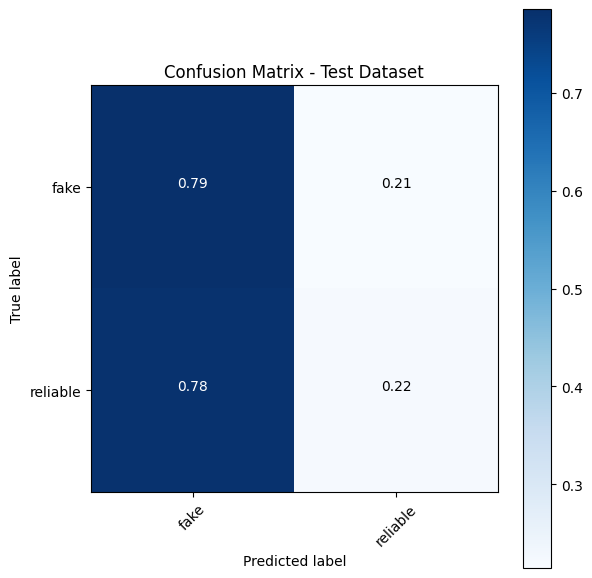

In [56]:
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib import pyplot as plt

cm_test = confusion_matrix(true_values, predicted_values)

np.set_printoptions(precision=2)

#plt.figure(figsize=(6,6))
#plot_confusion_matrix(cm_test, classes=label_values, title='Confusion Matrix - Test Dataset')
plt.figure(figsize=(6,6))
plot_confusion_matrix(cm_test, classes=label_values, title='Confusion Matrix - Test Dataset', normalize=True)